In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (accuracy_score, classification_report,
                             precision_recall_curve, roc_auc_score,
                             ConfusionMatrixDisplay, RocCurveDisplay)
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [2]:
df = pd.read_csv("online_shoppers_intention.csv")

#print(df.head())
#print(df.info())
#print(df.columns)

df["Revenue"]=df["Revenue"].astype(int)

print(df["Revenue"].value_counts())

print(df.head())

print(df.describe())

Revenue
0    10422
1     1908
Name: count, dtype: int64
   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
0         0.20       0.20         0.0         0.0   Feb                 1   
1 

In [3]:
df["Engagement"] = df["ProductRelated_Duration"] / (df["ProductRelated"] + 1)
df["Admin_Efficiency"] = df["Administrative_Duration"] / (df["Administrative"] + 1)

df["Total_Pages"] = df["Administrative"] + df["Informational"] + df["ProductRelated"]

df["Total_Duration"] = (
    df["Administrative_Duration"] +
    df["Informational_Duration"] +
    df["ProductRelated_Duration"]
)


In [4]:
categorical_cols = [
    "Month", "VisitorType", "OperatingSystems",
    "Browser", "Region", "TrafficType", "Weekend"
]

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df_encoded.drop("Revenue", axis=1)
y = df_encoded["Revenue"]


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
gb_model = GradientBoostingClassifier()
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))


Accuracy: 0.8925385239253852
              precision    recall  f1-score   support

           0       0.92      0.95      0.94      2055
           1       0.72      0.58      0.64       411

    accuracy                           0.89      2466
   macro avg       0.82      0.77      0.79      2466
weighted avg       0.89      0.89      0.89      2466



In [9]:
feature_importance = pd.Series(gb_model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance.head(10))

PageValues                       0.749442
BounceRates                      0.043624
Month_Nov                        0.042132
Administrative                   0.025745
Total_Duration                   0.018985
ExitRates                        0.018768
Total_Pages                      0.015539
VisitorType_Returning_Visitor    0.013519
ProductRelated_Duration          0.012564
Administrative_Duration          0.009053
dtype: float64


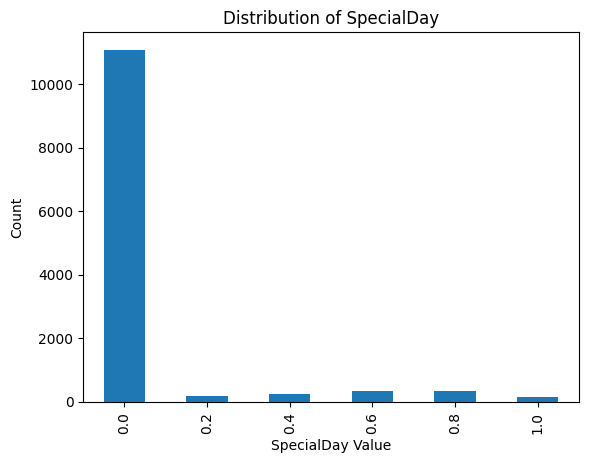

SpecialDay
0.0    0.165268
0.2    0.078652
0.4    0.053498
0.6    0.082621
0.8    0.033846
1.0    0.064935
Name: Revenue, dtype: float64


In [8]:
df["SpecialDay"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("SpecialDay Value")
plt.ylabel("Count")
plt.title("Distribution of SpecialDay")
plt.show()

special_rate=df.groupby("SpecialDay")["Revenue"].mean()
print(special_rate)
##

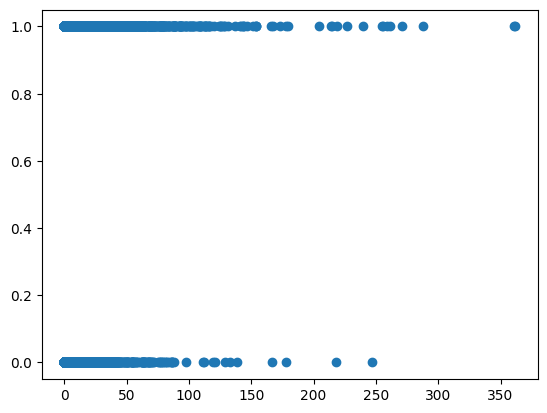

In [12]:
plt.scatter(df["PageValues"], df["Revenue"])
plt.show()

/tmp/ipykernel_6230/2209054976.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  purchase_rate = df.groupby("Admin_bin")["Revenue"].mean()


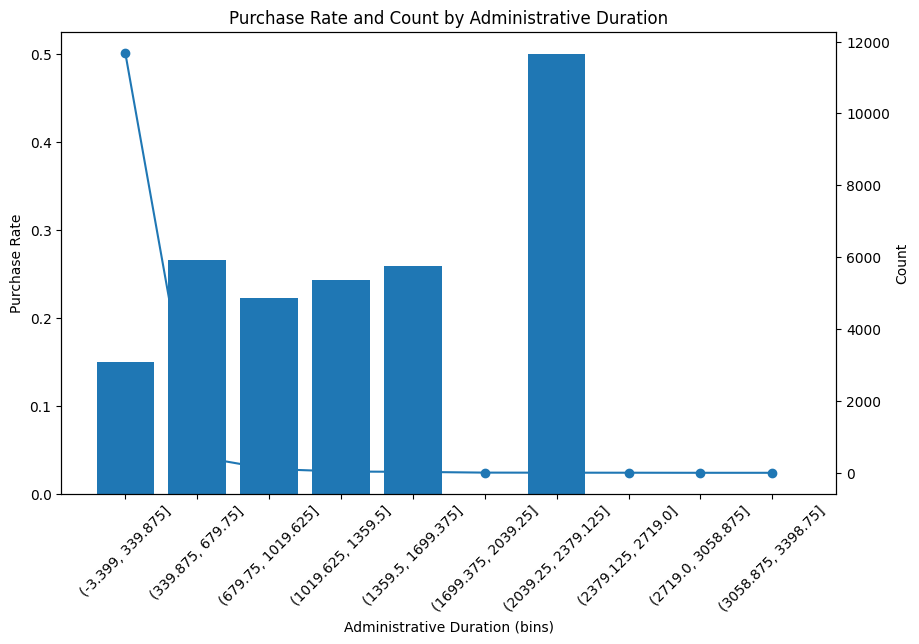

In [13]:
## Bar and line chart comparing admin_duration rate of purchase
df["Admin_bin"] = pd.cut(df["Administrative_Duration"], bins=10)

purchase_rate = df.groupby("Admin_bin")["Revenue"].mean()

counts = df["Admin_bin"].value_counts().sort_index()

# Plot
fig, ax1 = plt.subplots(figsize=(10,6))

# Bar chart (purchase rate)
ax1.bar(purchase_rate.index.astype(str), purchase_rate.values)
ax1.set_ylabel("Purchase Rate", color="black")
ax1.set_xlabel("Administrative Duration (bins)")
ax1.tick_params(axis='x', rotation=45)

# Second axis (counts)
ax2 = ax1.twinx()
ax2.plot(purchase_rate.index.astype(str), counts.values, marker='o')
ax2.set_ylabel("Count", color="black")

plt.title("Purchase Rate and Count by Administrative Duration")
plt.show()



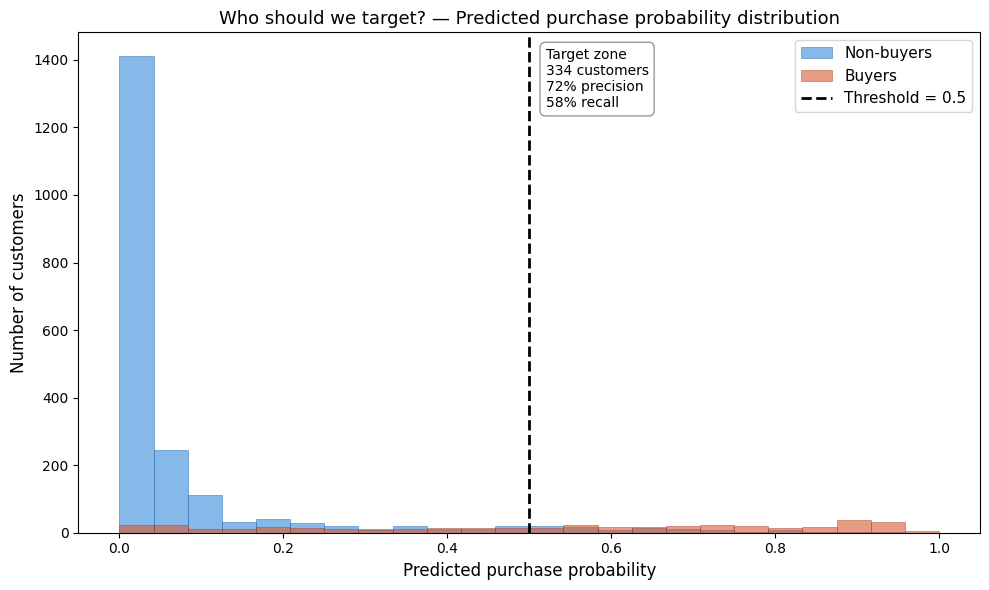

In [14]:
y_prob = gb_model.predict_proba(X_test)[:, 1]
threshold = 0.50

fig, ax = plt.subplots(figsize=(10, 6))

bins = np.linspace(0, 1, 25)

ax.hist(y_prob[y_test == 0], bins=bins, alpha=0.6,
        color="#378ADD", label="Non-buyers", edgecolor="#185FA5", linewidth=0.5)
ax.hist(y_prob[y_test == 1], bins=bins, alpha=0.6,
        color="#D85A30", label="Buyers",     edgecolor="#993C1D", linewidth=0.5)

ax.axvline(threshold, color="black", linestyle="--", linewidth=2,
           label=f"Threshold = {threshold}")

targeted   = (y_prob >= threshold).sum()
true_buy   = ((y_prob >= threshold) & (y_test == 1)).sum()
precision  = true_buy / targeted * 100
recall     = true_buy / (y_test == 1).sum() * 100

ax.text(threshold + 0.02, ax.get_ylim()[1] * 0.85,
        f"Target zone\n{targeted} customers\n{precision:.0f}% precision\n{recall:.0f}% recall",
        fontsize=10, color="black",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray", alpha=0.8))

ax.set_xlabel("Predicted purchase probability", fontsize=12)
ax.set_ylabel("Number of customers", fontsize=12)
ax.set_title("Who should we target? — Predicted purchase probability distribution", fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()